# Wordle: Gemma + LoRA + ES

Train a **linear head** on a Hugging Face causal LM with **Evolution Strategies**. This Week 11 notebook keeps the full **`google/gemma-3-1b-it`** path available, but now defaults to a **smoke-test profile** so you can verify the workflow quickly before committing to a long run. Switch `RUN_PROFILE` in §2 to move from fast validation to the fuller Gemma setup.

**Also:** Richer prompts with **structured constraints** from feedback; optional **supervised warm-start** (cross-entropy to the secret word; label only, not in the prompt).

**Requires:** `torch`, `transformers>=4.50.0`, `jinja2>=3.1.0` for chat-template models such as Gemma, `numpy`, `matplotlib`. **`pip install peft`** only if `USE_LORA=True` in §2. First run downloads HF weights.

## 1. Environment and imports

`peft` is **not** imported here (only needed for `USE_LORA=True`). Install it yourself if you enable LoRA.

**If you see `apply_chat_template requires jinja2>=3.1.0`:** run `python -m pip install -U 'jinja2>=3.1.0'` in the active notebook environment, then restart the kernel.

**If you see `unexpected keyword argument 'normalize_gradient'`:** restart the kernel and run this cell again, or rely on `importlib.reload` below (re-run this cell after editing `src/es_wordle.py`).

In [1]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import torch

# Fall back to standard HF downloads; Xet caused import/download issues in this env.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

# Repo root + src on path (works from `notebooks/` or project root)
_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

# Always pick up the latest es_wordle.py (Jupyter caches imports)
import es_wordle
importlib.reload(es_wordle)
from es_wordle import train_es_wordle

import inspect
_sig = inspect.signature(train_es_wordle)
for _name in ("normalize_gradient", "eval_deterministic"):
    if _name not in _sig.parameters:
        raise RuntimeError(
            f"src/es_wordle.py is missing {_name}. Re-run the import cell after `importlib.reload`, or pull the latest repo."
        )

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps_backend = getattr(torch.backends, "mps", None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> tuple[dict, str]:
    if device.type != "cuda":
        return {}, "float32"
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}, "bfloat16"
    return {"torch_dtype": torch.float16}, "float16"


def _parse_version_tuple(version: str) -> tuple[int, ...]:
    parts = []
    for chunk in version.split("."):
        digits = ""
        for ch in chunk:
            if ch.isdigit():
                digits += ch
            else:
                break
        if not digits:
            break
        parts.append(int(digits))
    return tuple(parts)


def require_chat_template_support() -> None:
    try:
        import jinja2
    except ImportError as exc:
        raise ImportError(
            "Chat-template models require `jinja2>=3.1.0`. Install or upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        ) from exc

    installed = getattr(jinja2, "__version__", "0")
    if _parse_version_tuple(installed) < (3, 1, 0):
        raise ImportError(
            f"Chat-template models require `jinja2>=3.1.0`, but found {installed}. Upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        )


print("ROOT:", ROOT)
print("es_wordle:", es_wordle.__file__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("HF_HUB_DISABLE_XET:", os.environ["HF_HUB_DISABLE_XET"])
if torch.cuda.is_available():
    print("cuda_device:", torch.cuda.get_device_name(0))

ROOT: /home/ubuntu/stat4830Project/STAT-4830-project-base
es_wordle: /home/ubuntu/stat4830Project/STAT-4830-project-base/src/es_wordle.py
torch: 2.11.0+cu126 | cuda: True
HF_HUB_DISABLE_XET: 1
cuda_device: NVIDIA A100-SXM4-80GB


## 2. Hyperparameters

The next cell now supports two profiles:

- **`RUN_PROFILE="smoke"`**: fast validation path using a smaller model and short ES/warm-start settings.
- **`RUN_PROFILE="gemma_full"`**: restores the fuller Week 11 Gemma configuration for a real run.

Additional notes:

- **`MODEL_LOAD_KWARGS`**: automatically picks a GPU-friendly dtype on CUDA (`bfloat16` when supported, else `float16`). CPU stays on `float32`.
- **`USE_CHAT_TEMPLATE`**: stays enabled for Gemma instruction checkpoints and disabled for the smoke-test GPT-2 path.
- **`MOCK_ENV`**: remains `True` by default so validation runs stay bounded and always have the target word in the action set.
- **`N_POP` / `N_ITERATIONS` / `WARM_START_STEPS`**: are profile-controlled so the smoke path stays quick while the Gemma path keeps the heavier settings.
- **`USE_LORA`**: still defaults to `False` so validation only trains the head unless you explicitly enable adapters.

In [2]:
# --- Hyperparameters (switch RUN_PROFILE for longer runs) ---

SEED = 42
RUN_PROFILE = "gemma_full"  # "smoke" or "gemma_full"
DEVICE = choose_device()

MOCK_ENV = True
USE_PRIME_TARGETS = False
USE_LORA = False  # Leave False for validation; enable only if you want PEFT adapters.
LORA_R = 4
RICHER_PROMPT = True
WARM_START_LR = 3e-4
SIGMA = 0.02
ALPHA = 0.12
NORMALIZE_GRADIENT = True
RANK_FITNESS = True
EVAL_DETERMINISTIC = True  # greedy eval: Success % reflects argmax policy (clearer after warm-start)
FITNESS_OBJECTIVE = "win_plus_return"
WIN_FITNESS_SCALE = 8.0

PROFILE_CONFIGS = {
    "smoke": {
        "model_name": "distilgpt2",
        "use_chat_template": False,
        "chat_generation_prompt": False,
        "max_prompt_length": 256,
        "max_vocab": 8,
        "n_eval_episodes": 1,
        "eval_n_episodes": 4,
        "eval_every": 1,
        "warm_start_steps": 12,
        "n_pop": 4,
        "n_iterations": 2,
        "num_train_examples": 128,
        "num_eval_examples": 16,
    },
    "gemma_full": {
        "model_name": "google/gemma-3-1b-it",
        "use_chat_template": True,
        "chat_generation_prompt": True,
        "max_prompt_length": 512,
        "max_vocab": None,
        "n_eval_episodes": 2,
        "eval_n_episodes": 24,
        "eval_every": 10,
        "warm_start_steps": 400,
        "n_pop": 16,
        "n_iterations": 10,
        "num_train_examples": 2000,
        "num_eval_examples": 20,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"RUN_PROFILE must be one of {sorted(PROFILE_CONFIGS)}, got {RUN_PROFILE!r}")

cfg = PROFILE_CONFIGS[RUN_PROFILE]
MODEL_NAME = cfg["model_name"]
USE_CHAT_TEMPLATE = cfg["use_chat_template"]
if USE_CHAT_TEMPLATE:
    require_chat_template_support()
CHAT_GENERATION_PROMPT = cfg["chat_generation_prompt"]
MAX_PROMPT_LENGTH = cfg["max_prompt_length"]
N_EVAL_EPISODES = cfg["n_eval_episodes"]
EVAL_N_EPISODES = cfg["eval_n_episodes"]
EVAL_EVERY = cfg["eval_every"]
WARM_START_STEPS = cfg["warm_start_steps"]
N_POP = cfg["n_pop"]
N_ITERATIONS = cfg["n_iterations"]
NUM_TRAIN_EXAMPLES = cfg["num_train_examples"]
NUM_EVAL_EXAMPLES = cfg["num_eval_examples"]

# Mock: action space == secret pool only → every episode solvable; ES / eval see real wins.
if MOCK_ENV:
    from wordle_env import MOCK_WORDLE_TARGETS as _MOCK_T
    _MOCK_ACTIONS = len(_MOCK_T)
else:
    _MOCK_ACTIONS = None

MAX_VOCAB = _MOCK_ACTIONS if MOCK_ENV else cfg["max_vocab"]
MODEL_LOAD_KWARGS, MODEL_DTYPE_NAME = default_model_load_kwargs(DEVICE)

np.random.seed(SEED)
torch.manual_seed(SEED)

device = DEVICE
print(
    f"Profile: {RUN_PROFILE} | Model: {MODEL_NAME} | chat_template: {USE_CHAT_TEMPLATE} | LoRA: {USE_LORA}\n"
    f"  device={device}  model_dtype={MODEL_DTYPE_NAME}  MAX_PROMPT_LENGTH={MAX_PROMPT_LENGTH}  MAX_VOCAB={MAX_VOCAB}\n"
    f"  ES: N_POP={N_POP}  N_ITERATIONS={N_ITERATIONS}  n_eval_episodes={N_EVAL_EPISODES}  "
    f"eval_n_episodes={EVAL_N_EPISODES}  WARM_START_STEPS={WARM_START_STEPS}"
)
if MODEL_LOAD_KWARGS:
    print("model_load_kwargs:", MODEL_LOAD_KWARGS)

Profile: gemma_full | Model: google/gemma-3-1b-it | chat_template: True | LoRA: False
  device=cuda  model_dtype=bfloat16  MAX_PROMPT_LENGTH=512  MAX_VOCAB=8
  ES: N_POP=16  N_ITERATIONS=10  n_eval_episodes=2  eval_n_episodes=24  WARM_START_STEPS=400
model_load_kwargs: {'torch_dtype': torch.bfloat16}


## 3. Build policy and environment

First execution downloads the tokenizer + weights for `MODEL_NAME` into the HF cache.

For `RUN_PROFILE="smoke"`, this should stay quick and use the small GPT-2 path. For `RUN_PROFILE="gemma_full"`, expect a larger download and a much heavier run.

`MODEL_LOAD_KWARGS` now passes a GPU-friendly dtype into the Hugging Face model loader when CUDA is available.

With `include_mock_targets_in_vocab=True` (default), the first actions include all `MOCK_WORDLE_TARGETS` so a random mock secret word is always in the action set.

Set `USE_LORA=True` in §2 for PEFT LoRA — run **`pip install peft`** before this cell. With `USE_LORA=False`, only the head is trained (faster ES).

In [3]:
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

from wordle_env import MOCK_WORDLE_TARGETS
assert all(w in policy.words for w in MOCK_WORDLE_TARGETS)

print(f"Trainable (ES): {policy.count_trainable_parameters():,}")
print(f"Total params:   {policy.count_parameters():,}")
print(f"Action dim:     {policy.action_dim}")
print(f"Chat template:  {policy.use_chat_template}")
print(f"Load kwargs:    {MODEL_LOAD_KWARGS or {'torch_dtype': 'float32'}}")

env = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Trainable (ES): 9,224
Total params:   999,895,176
Action dim:     8
Chat template:  True
Load kwargs:    {'torch_dtype': torch.bfloat16}
[OK] Mock Wordle environment (Prime Intellect disabled; targets from MOCK_WORDLE_TARGETS).


## 4. Optional supervised warm-start

Random play for 1–4 guesses, then **cross-entropy** toward the secret word (the answer is **not** in the prompt). Set `WARM_START_STEPS = 0` to skip.

In [4]:
from wordle_gpt2_warmstart import supervised_warm_start_wordle

if WARM_START_STEPS > 0:
    ws = supervised_warm_start_wordle(
        policy,
        env,
        n_steps=WARM_START_STEPS,
        lr=WARM_START_LR,
        device=device,
        seed=SEED,
        verbose=True,
    )
    print("Warm-start: fitted", len(ws["loss"]), "steps; skipped", ws["skipped"])
else:
    print("Skipping warm-start.")


  warm-start 80/400 | loss=3.7076 | skipped=0
  warm-start 160/400 | loss=2.8167 | skipped=0
  warm-start 240/400 | loss=3.3353 | skipped=0
  warm-start 320/400 | loss=3.3514 | skipped=0
  warm-start 400/400 | loss=2.7502 | skipped=0
Warm-start: fitted 400 steps; skipped 0


## 5. Run ES training

`train_es_wordle` prints **every iteration** when `verbose=True`. **`‖θ−θ₀‖`** is the L2 distance of trainable weights from their **initial** values — it should **grow** every step (proof the optimizer is changing parameters). **`Step‖`** is often **constant** when `NORMALIZE_GRADIENT=True` (fixed step length by design). **`popσ`** is spread of fitness across the ES population (noise).

`history` now includes **`train_iter`, `train_fitness`, `param_drift`, `pop_fitness_std`, …** every iteration (not only eval checkpoints). The plot cell uses them in the **bottom row**.

Full eval lines (Success / Eval Reward) appear when `iteration % EVAL_EVERY == 0` or on the last iteration.

In [5]:
history = train_es_wordle(
    policy=policy,
    env=env,
    N=N_POP,
    sigma=SIGMA,
    alpha=ALPHA,
    n_iterations=N_ITERATIONS,
    n_eval_episodes=N_EVAL_EPISODES,
    max_turns=6,
    eval_every=EVAL_EVERY,
    verbose=True,
    normalize_gradient=NORMALIZE_GRADIENT,
    eval_n_episodes=EVAL_N_EPISODES,
    rank_fitness=RANK_FITNESS,
    eval_deterministic=EVAL_DETERMINISTIC,
    fitness_objective=FITNESS_OBJECTIVE,
    win_fitness_scale=WIN_FITNESS_SCALE,
)

Iter    0 | Fit(win+ret):  7.251 | ES_win: 68.8% | popσ: 2.2081 | Eval Reward:  1.902 | Success: 79.2% (greedy) | Turns:  3.7 | Grad‖: 1165.80 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  9.280 | ES_win: 90.6% | popσ: 1.7330 | Grad‖: 1161.10 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17 | (no eval)
Iter    2 | Fit(win+ret):  7.931 | ES_win: 75.0% | popσ: 2.2309 | Grad‖: 1156.57 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21 | (no eval)
Iter    3 | Fit(win+ret):  8.714 | ES_win: 84.4% | popσ: 2.0737 | Grad‖: 1159.48 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.24 | (no eval)
Iter    4 | Fit(win+ret):  8.191 | ES_win: 78.1% | popσ: 2.7713 | Grad‖: 1153.67 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.27 | (no eval)
Iter    5 | Fit(win+ret):  8.167 | ES_win: 78.1% | popσ: 2.2102 | Grad‖: 1174.53 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.29 | (no eval)
Iter    6 | Fit(win+ret):  8.944 | ES_win: 87.5% | popσ: 1.9855 | Grad‖: 1158.08 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.32 | (no eval)
Iter    7 | Fit(win+ret):  7.886 | ES_win: 75.0% | popσ: 2.7288 | Grad‖: 1155.18 |

## 6. Plot training curves

mkdir -p failed for path /home/ubuntu/.config/matplotlib: [Errno 13] Permission denied: '/home/ubuntu/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-nwzfgz7j because there was an issue with the default path (/home/ubuntu/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


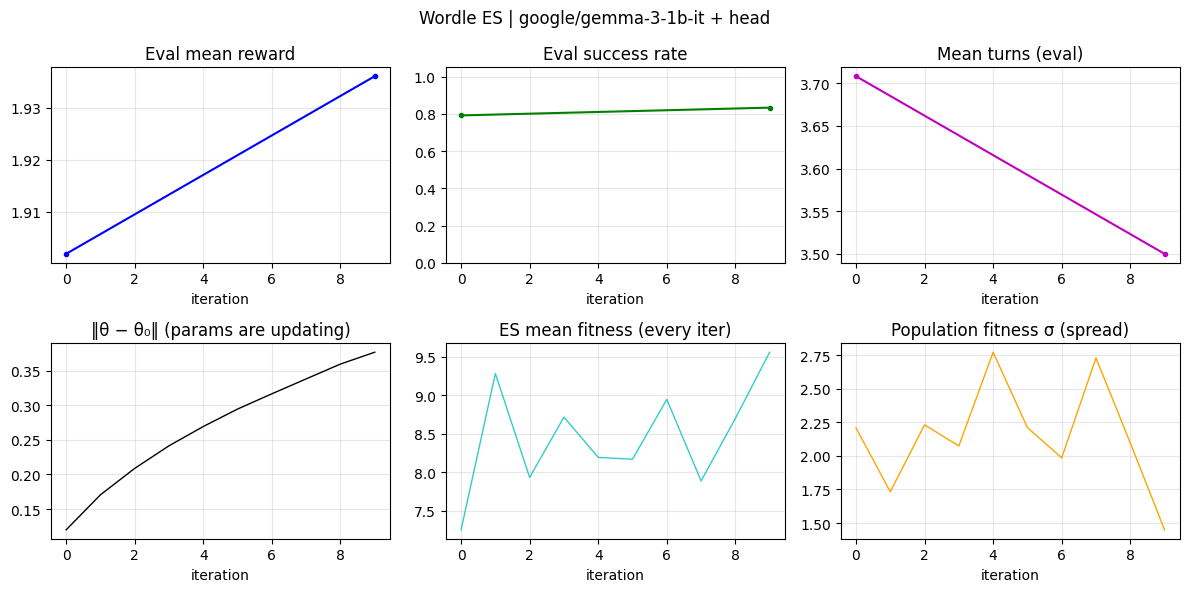

In [6]:
import matplotlib.pyplot as plt

it = history["iteration"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0, 0].plot(it, history["eval_reward"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("iteration")
axes[0, 2].grid(True, alpha=0.3)

ti = history["train_iter"]
axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (params are updating)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ti, history["train_fitness"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("ES mean fitness (every iter)")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(ti, history["pop_fitness_std"], "orange", lw=1)
axes[1, 2].set_title("Population fitness σ (spread)")
axes[1, 2].set_xlabel("iteration")
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"Wordle ES | {MODEL_NAME} + head")
plt.tight_layout()
plt.show()

## 7. Save checkpoint (optional)

Saves the **head** (and **LoRA adapter** if `USE_LORA=True`) plus `words` and `history` under `models/` at the repo root. The filename now includes `RUN_PROFILE` so a quick smoke-test save does not overwrite a fuller Gemma run.

In [7]:
if USE_LORA:
    save_path = ROOT / "models" / f"wordle_gemma_es_head_LoRA.{RUN_PROFILE}.pt"
else:
    save_path = ROOT / "models" / f"wordle_gemma_es_head.{RUN_PROFILE}.pt"
    
save_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "head": policy.head.state_dict(),
    "model_name": MODEL_NAME,
    "words": policy.words,
    "history": history,
    "use_lora": USE_LORA,
    "run_profile": RUN_PROFILE,
    "model_load_kwargs": {k: str(v) for k, v in MODEL_LOAD_KWARGS.items()},
}
if getattr(policy, "_lm_trainable", False):
    payload["lm"] = policy.lm.state_dict()
torch.save(payload, save_path)
print("Saved:", save_path)

Saved: /home/ubuntu/stat4830Project/STAT-4830-project-base/models/wordle_gemma_es_head.gemma_full.pt
